# Epidemic Network
Python implementation of NASSA module 2022-Vlach-001
(Vlach, M. 2022. *The Antonine Plague: Evaluation of its Impact through Epidemiological Modelling*.
In Brughmans, T. & Wilson, A. (eds.), *Simulating Roman Economies*. Oxford University Press, pp. 69–108.)

This notebook demonstrates how to use the `epidemicNetwork_v01` module to:
- initialise and configure an epidemic network model on a clustered settlement landscape,
- run the SEIRD disease-spread simulation,
- produce a spatial disease map replicating the NetLogo interface,
- generate a dashboard of simulation-result distributions.

Import dependencies:

In [1]:
import pathlib
import matplotlib
matplotlib.use('inline')

Import `epidemicNetwork_v01` module:

In [2]:
import epidemicNetwork_v01 as en_01

## Parameters
The model's global constants are defined at the top of `epidemicNetwork_v01.py`.
They replicate the sliders and switches in the original NetLogo interface.
Inspect the default values:

In [3]:
### NetLogo 'seed' slider
print(f"SEED                       = {en_01.SEED}")

### NetLogo 'initial-households' slider
print(f"INITIAL_HOUSEHOLDS         = {en_01.INITIAL_HOUSEHOLDS}")

### NetLogo 'population-coefficient' slider
print(f"POPULATION_COEFFICIENT     = {en_01.POPULATION_COEFFICIENT}")

### NetLogo 'initial-clusters' slider
print(f"INITIAL_CLUSTERS           = {en_01.INITIAL_CLUSTERS}")

### NetLogo 'search-radius' slider
print(f"SEARCH_RADIUS              = {en_01.SEARCH_RADIUS}")

### NetLogo 'max-connections' slider
print(f"MAX_CONNECTIONS            = {en_01.MAX_CONNECTIONS}")

### NetLogo 'initial-infected' slider
print(f"INITIAL_INFECTED           = {en_01.INITIAL_INFECTED}")

### NetLogo 'spread-rate' slider
print(f"SPREAD_RATE                = {en_01.SPREAD_RATE}")

### NetLogo 'mortality-rate' slider
print(f"MORTALITY_RATE             = {en_01.MORTALITY_RATE}")

### NetLogo 'max-ticks' stop condition
print(f"MAX_TICKS                  = {en_01.MAX_TICKS}")

SEED                       = 123
INITIAL_HOUSEHOLDS         = 1000
POPULATION_COEFFICIENT     = 3.0
INITIAL_CLUSTERS           = 30
SEARCH_RADIUS              = 100
MAX_CONNECTIONS            = 5
INITIAL_INFECTED           = 10
SPREAD_RATE                = 25.0
MORTALITY_RATE             = 20.0
MAX_TICKS                  = 300


## Initialisation
Instantiate `EpidemicModel` and call `setup()` to:
- generate clustered settlement candidates (`setup-clusters` in NetLogo),
- place households and people on sampled points (`setup-population`),
- build the distance-stratified social network (`setup-people-network`),
- seed the initial infected cases near the geographic centre (`start-epidemic`).

In [4]:
### instantiate the model (seeds both random generators)
model = en_01.EpidemicModel()

### run the full setup sequence: clusters → population → network → epidemic seed
model.setup()

### inspect the initial model state
print(f"Total people:              {len(model.people)}")
print(f"Total households:          {len(model.households)}")
print(f"Total social links:        {len(model.connections)}")
print(f"Initial infected (tick 0): {model.stats['infected'][0]}")

Total people:              6523
Total households:          1000
Total social links:        22594
Initial infected (tick 0): 10


## Running the simulation
Call `run()` to execute up to `MAX_TICKS` ticks.
The loop stops earlier if no infectious cases remain (epidemic ended naturally),
replicating the NetLogo 'go' button stop condition:

In [5]:
### advance the simulation for up to MAX_TICKS ticks
model.run()

### summarise the completed simulation
print(f"Simulation finished at tick: {model.tick}")
print(f"Final susceptible:           {model.stats['susceptible'][-1]}")
print(f"Final recovered:             {model.stats['recovered'][-1]}")
print(f"Final died:                  {model.stats['died'][-1]}")

Simulation finished at tick: 116
Final susceptible:           6481
Final recovered:             31
Final died:                  11


## Visualisation: spatial disease map
Replicate the NetLogo interface spatial view:
- Black background with coloured agents (dodgerblue = susceptible, red = incubation,
  green = prodromal, yellow = contagious, orange = recovered, brown = died).
- Red lines connect agents through which disease was transmitted in the last 100 ticks.
- Three time-series plots: epidemic stages, population outcomes, daily contacts/transmissions.

Replicates the NetLogo `visualise` procedure and monitor plots:

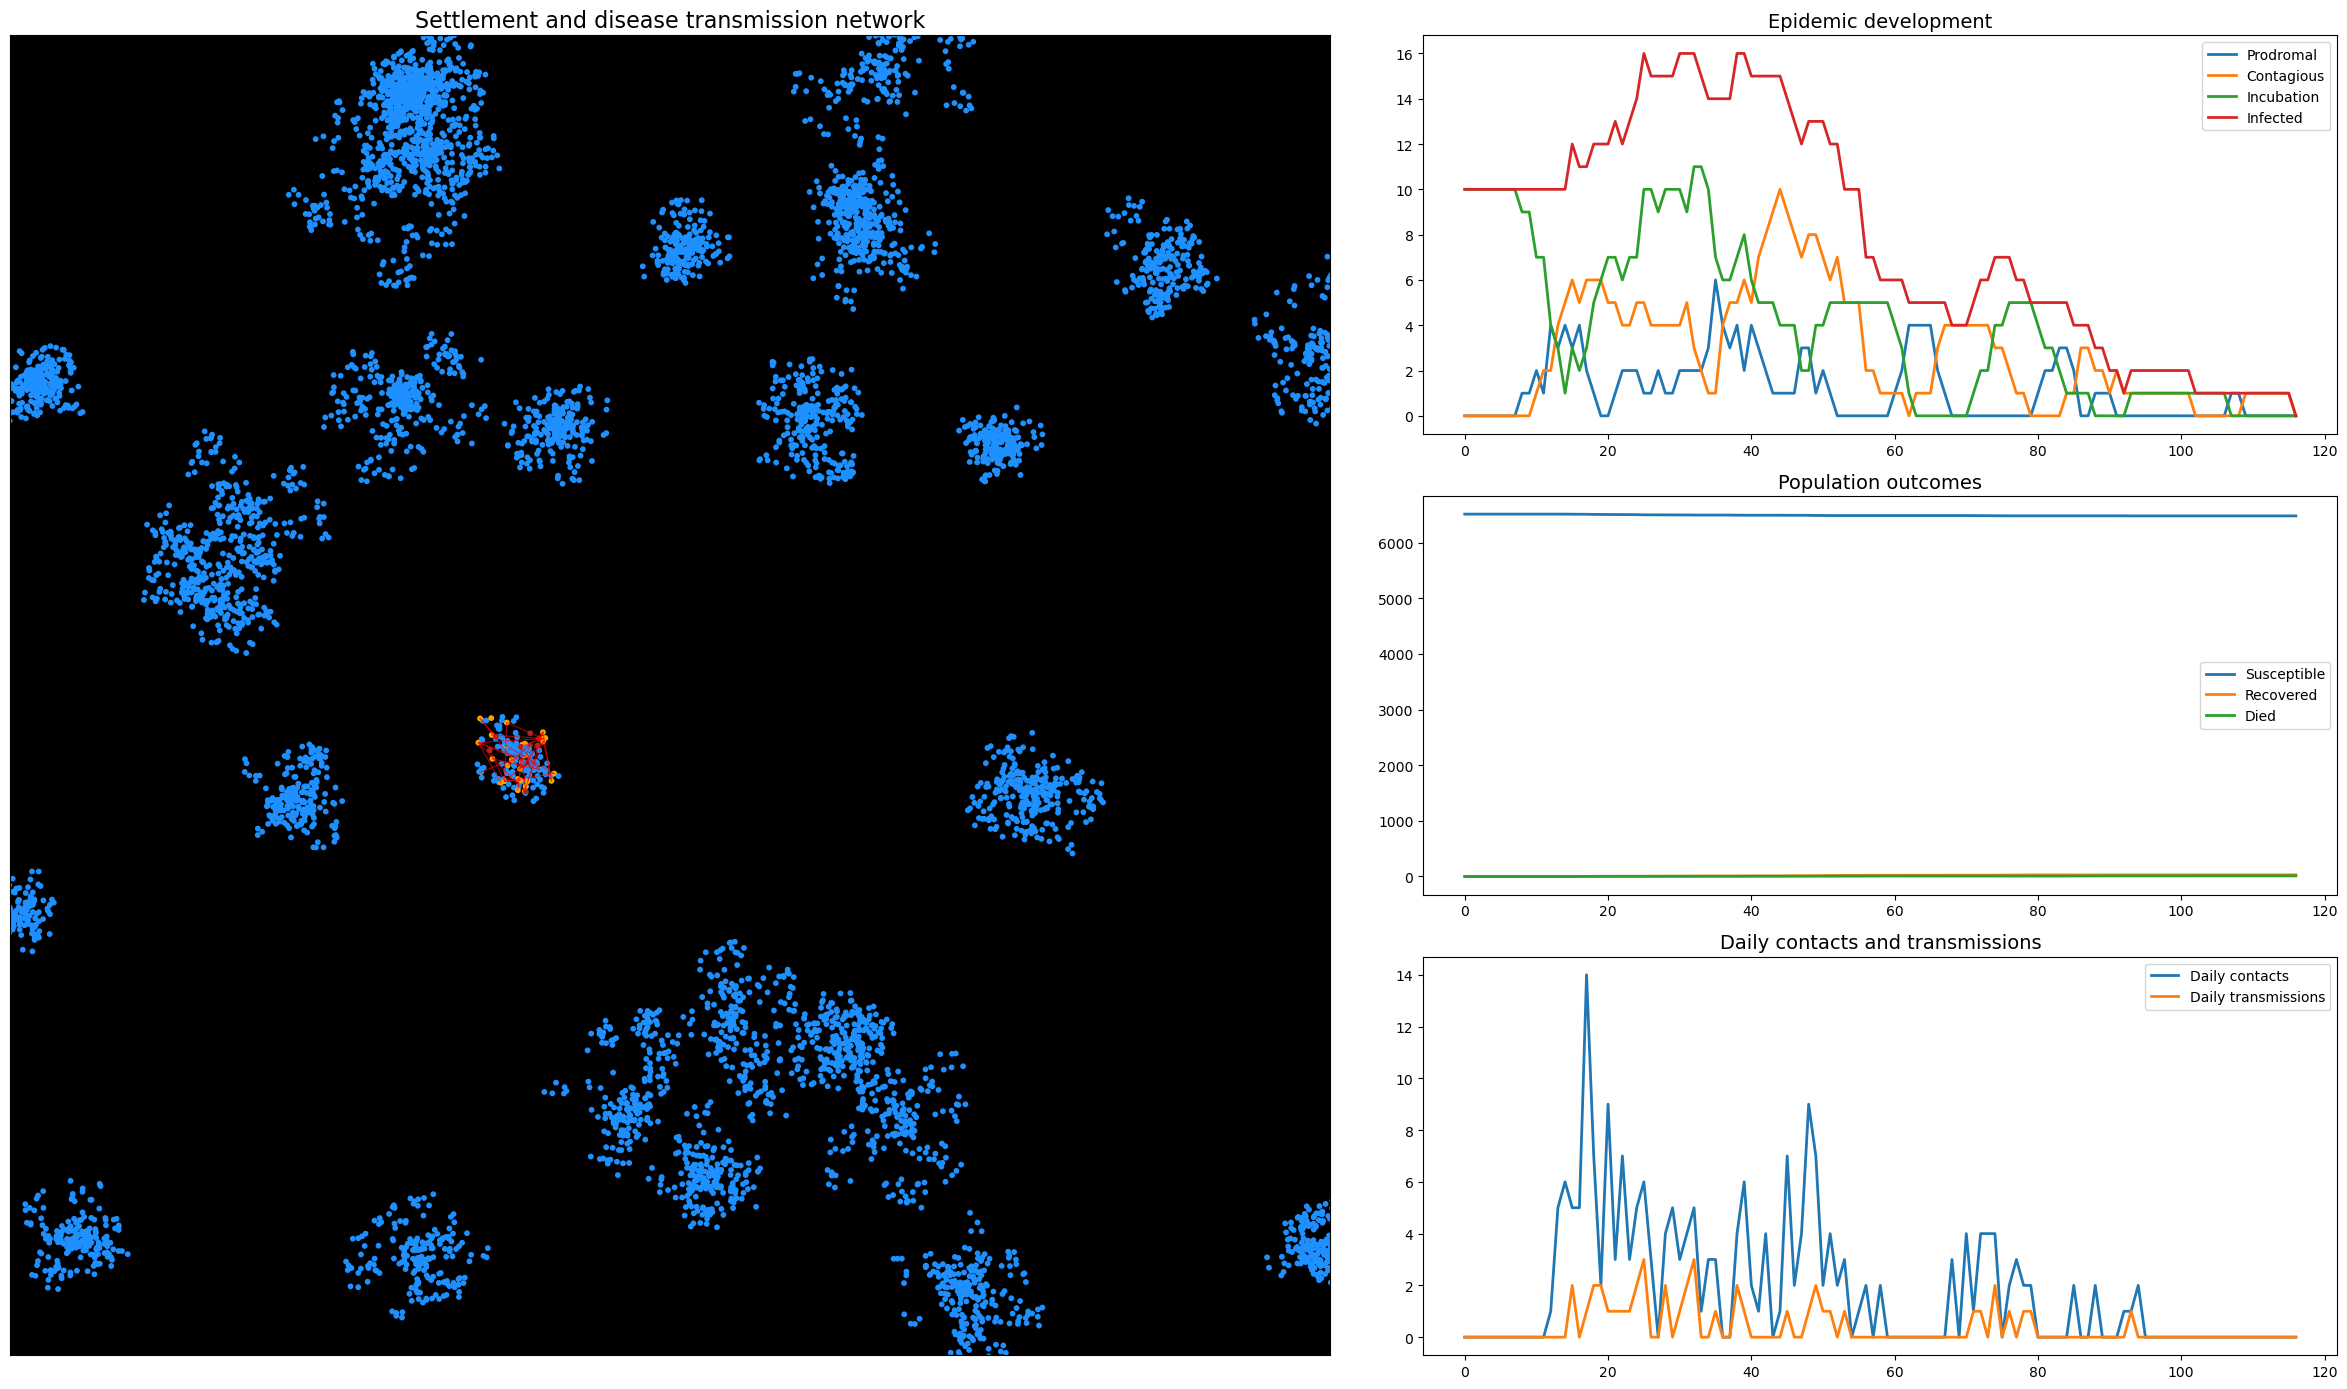

In [6]:
### produce the four-panel spatial + time-series figure
### equivalent to the NetLogo 'visualise' procedure and monitor panels
en_01.plot_model(model)

## Visualisation: simulation results dashboard
Produce a 4×3 grid of histograms summarising the simulation outcomes:
- Network structure: link lengths, degree distribution, household sizes, transmission probabilities.
- Disease stage durations: prodromal, contagious, latent, whole illness.
- Terminal events: illness duration at death and at immobility onset.

Replicates the NetLogo histogram monitors and BehaviorSpace output plots:

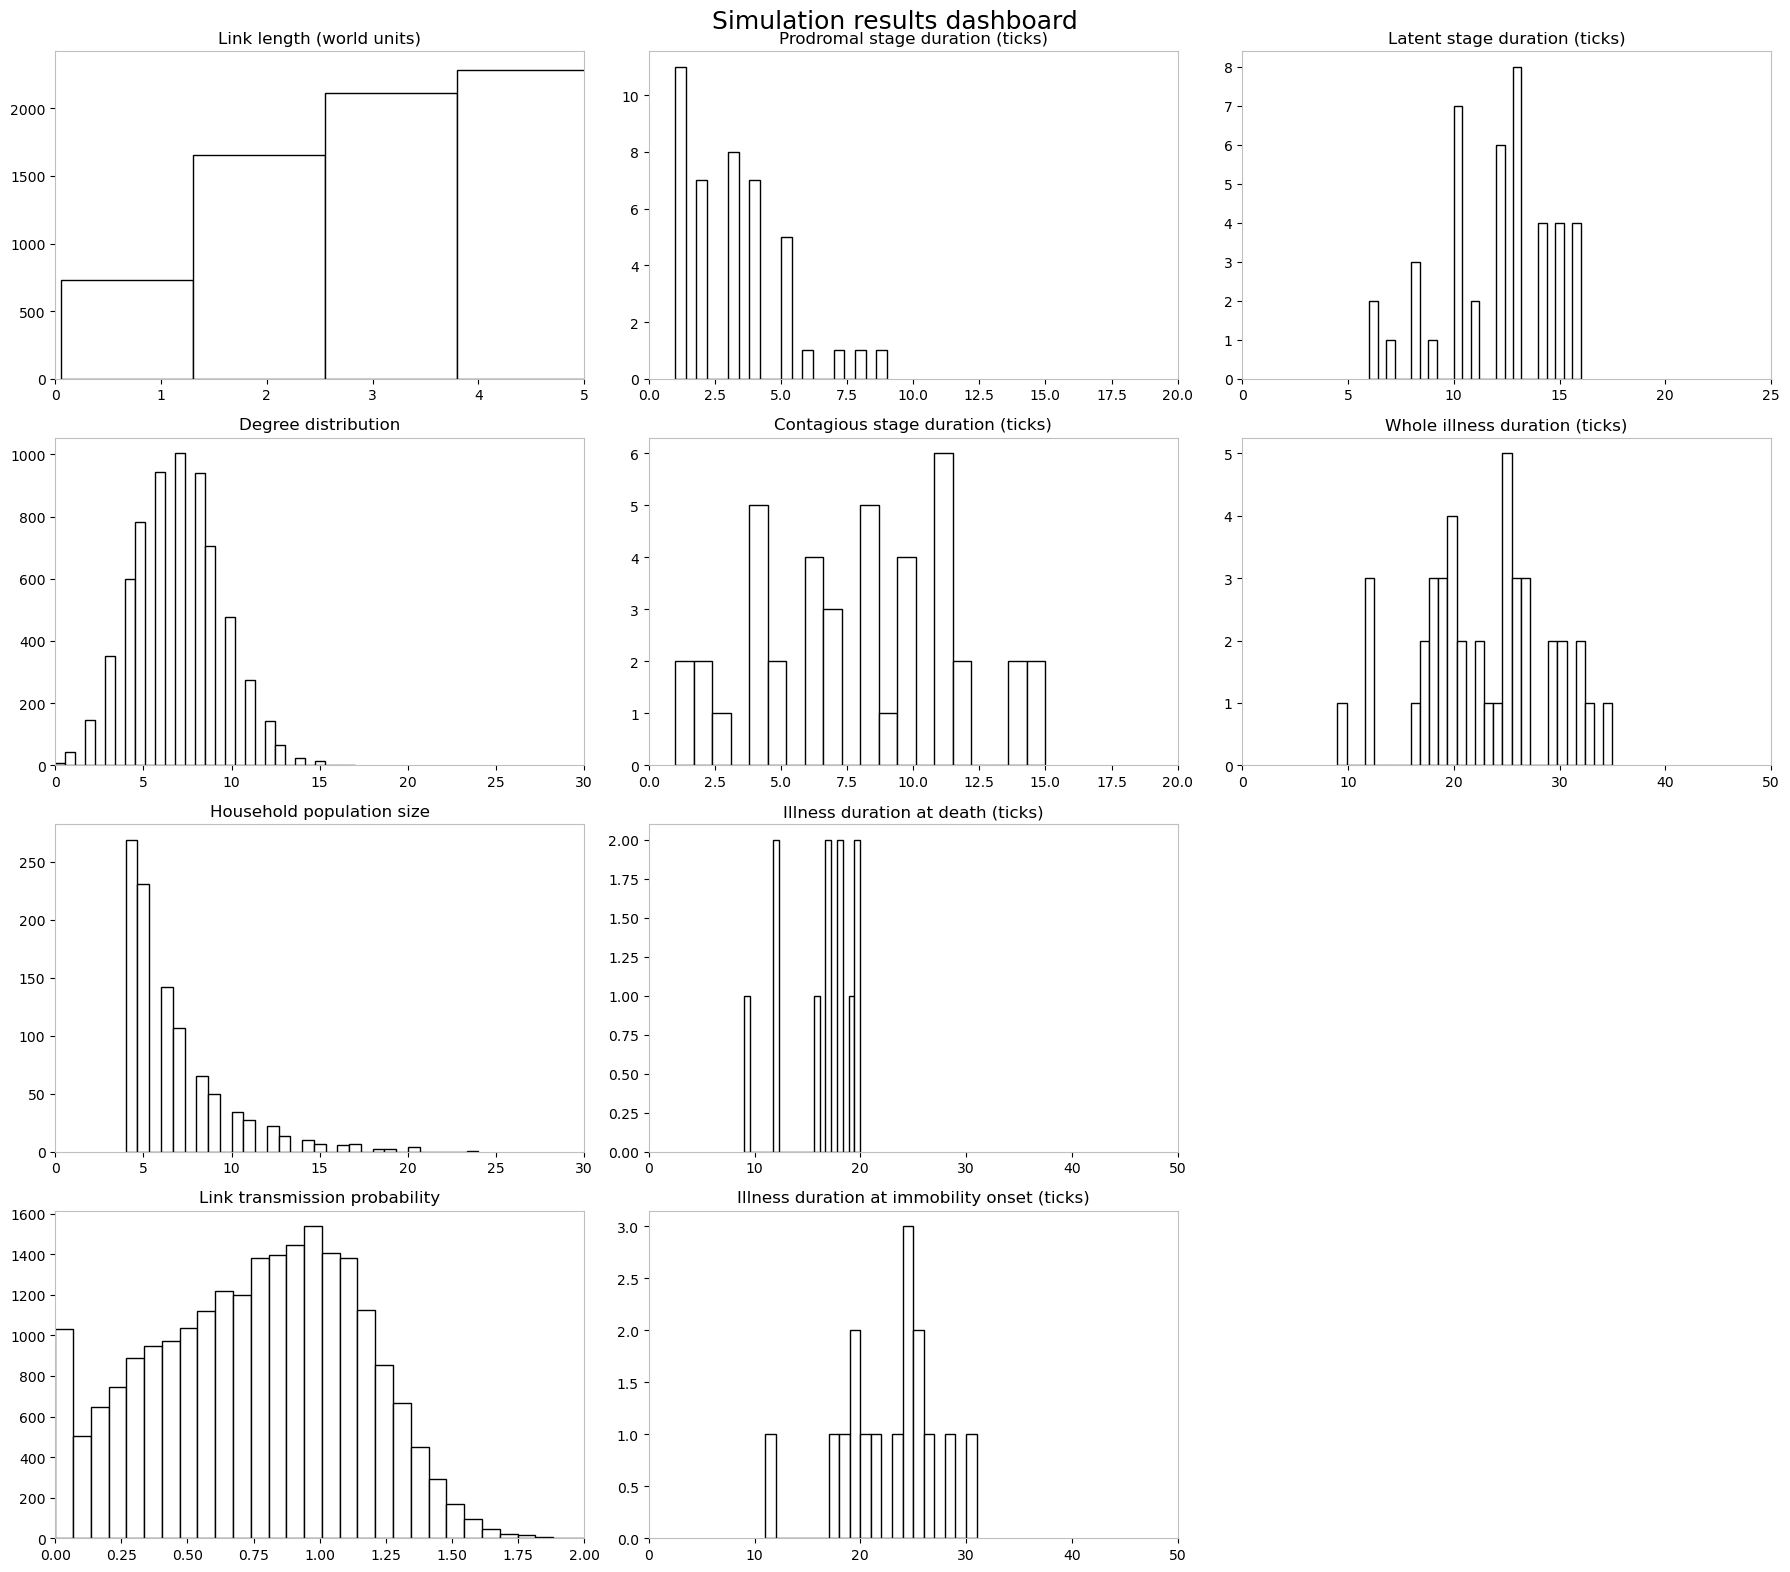

In [8]:
### produce the 4×3 histogram dashboard
### equivalent to the NetLogo histogram monitors
en_01.plot_histograms(model)